![image info](https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/images/banner_1.png)

# Proyecto 1 - Predicción de popularidad en canción

En este proyecto podrán poner en práctica sus conocimientos sobre modelos predictivos basados en árboles y ensambles, y sobre la disponibilización de modelos. Para su desarrollo tengan en cuenta las instrucciones dadas en la "Guía del proyecto 1: Predicción de popularidad en canción".

**Entrega**: La entrega del proyecto deberán realizarla durante la semana 4. Sin embargo, es importante que avancen en la semana 3 en el modelado del problema y en parte del informe, tal y como se les indicó en la guía.

Para hacer la entrega, deberán adjuntar el informe autocontenido en PDF a la actividad de entrega del proyecto que encontrarán en la semana 4, y subir el archivo de predicciones a la competencia de Kaggle cuyo link estará disponible en la sección del Coursera del proyecto.

## Datos para la predicción de popularidad en cancion

En este proyecto se usará el conjunto de datos de datos de popularidad en canciones, donde cada observación representa una canción y se tienen variables como: duración de la canción, acusticidad y tempo, entre otras. El objetivo es predecir qué tan popular es la canción. Para más detalles puede visitar el siguiente enlace: [datos](https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset).

## Carga de datos y librerias


In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [152]:
# Importación librerías
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
import re
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                               GradientBoostingRegressor, AdaBoostRegressor,
                               HistGradientBoostingRegressor, BaggingRegressor)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import f_regression
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

In [4]:
# Carga de datos de archivo .csv
dataTraining = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2026/main/datasets/dataTrain_Spotify.csv')
dataTesting = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2026/main/datasets/dataTest_Spotify.csv', index_col=0)

In [11]:
# Visualización datos de entrenamiento
dataTraining.head(3)

,Unnamed: 0,track_id,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity
0,0,7hUhmkALyQ8SX9mJs5XI3D,Love and Rockets,Love and Rockets,Motorcycle,211533,False,0.305,0.849,9,...,1,0.0549,0.000058,0.056700,0.4640,0.320,141.793,4,goth,22
1,1,5x59U89ZnjZXuNAAlc8X1u,Filippa Giordano,Filippa Giordano,"Addio del passato - From ""La traviata""",196000,False,0.287,0.190,7,...,0,0.0370,0.930000,0.000356,0.0834,0.133,83.685,4,opera,22
2,2,70Vng5jLzoJLmeLu3ayBQq,Susumu Yokota,Symbol,Purple Rose Minuet,216506,False,0.583,0.509,1,...,1,0.0362,0.777000,0.202000,0.1150,0.544,90.459,3,idm,37


### Exploración y preprocesamiento

Los datos de entrenamiento se dividen en datos de entrenamiento y validación. Si decidieron preprocesar los datos (estandarizar, normalizar, imputar valores, etc), estos son correctamente preprocesados al ajustar sobre los datos de entrenamiento (.fit_transform()) y al transformar los datos del set de validación (.transform()). (10 puntos)

In [121]:
# Division en train y test

# Features
X = dataTraining.drop(columns=[
    'popularity',
    'track_id',
    'artists',
    'track_genre',
    'album_name',
    'track_name',
    'Unnamed__0'
])

# Target
y = dataTraining['popularity']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


X_train_orig = X_train.copy()
X_test_orig  = X_test.copy()

In [70]:
def clean_col_names(df):
    df.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in df.columns]
    return df

dataTraining = clean_col_names(dataTraining)
dataTesting = clean_col_names(dataTesting)

In [74]:
print(len(dataTraining))
print(dataTraining.shape)
print(len(dataTesting))
print(dataTraining.shape)

79800
(79800, 21)
34200
(79800, 21)


In [74]:
# Ver distintos
for col in dataTrmaining.coluns:
    print(f"\n{col}: {dataTraining[col].unique()[:10]}")

In [73]:
tabla_unicos = pd.DataFrame({
    "valores_unicos": dataTraining.nunique()
})

tabla_unicos.sort_values('valores_unicos', ascending = False).head(5)

,valores_unicos
Unnamed__0,79800
track_id,66720
track_name,55767
duration_ms,40712
album_name,37315


In [75]:
# Tipos de datos
tipos = dataTraining.dtypes.groupby(dataTraining.dtypes).groups
print(tipos)

conteo_tipos = dataTraining.dtypes.value_counts()
print(conteo_tipos)

{bool: ['explicit'], int64: ['Unnamed__0', 'duration_ms', 'key', 'mode', 'time_signature', 'popularity'], float64: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'], object: ['track_id', 'artists', 'album_name', 'track_name', 'track_genre']}
float64    9
int64      6
object     5
bool       1
Name: count, dtype: int64


In [76]:
# Valores Nulos
tabla_nulos = pd.DataFrame({
    "nulos": dataTraining.isnull().sum(),
    "porcentaje": (dataTraining.isnull().mean() * 100).round(2)
})

# filtrar solo variables con nulos
tabla_nulos = tabla_nulos[tabla_nulos["nulos"] > 0]

tabla_nulos

,nulos,porcentaje


In [77]:
tabla_nulos.describe().T

,count,mean,std,min,25%,50%,75%,max
nulos,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
porcentaje,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [79]:
# Seleccionar solo columnas numéricas
numeric_cols = dataTraining.select_dtypes(include='number').columns

Q1 = dataTraining[numeric_cols].quantile(0.25)
Q3 = dataTraining[numeric_cols].quantile(0.75)

IQR = Q3 - Q1

limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

tabla_outliers = pd.DataFrame({
    "Q1": Q1,
    "Q3": Q3,
    "IQR": IQR,
    "lim_inf": limite_inf,
    "lim_sup": limite_sup
})

tabla_outliers["n_outliers"] = [
    ((dataTraining[col] < limite_inf[col]) | (dataTraining[col] > limite_sup[col])).sum()
    for col in numeric_cols
]

tabla_outliers["pct_outliers"] = (tabla_outliers["n_outliers"] / len(dataTraining) * 100).round(2)

tabla_outliers.sort_values("n_outliers", ascending=False)

,Q1,Q3,IQR,lim_inf,lim_sup,n_outliers,pct_outliers
instrumentalness,0.00000,0.0505,0.05050,-0.075750,0.126250,17645,22.11
speechiness,0.03590,0.0845,0.04860,-0.037000,0.157400,9277,11.63
time_signature,4.00000,4.0000,0.00000,4.000000,4.000000,8598,10.77
liveness,0.09790,0.2730,0.17510,-0.164750,0.535650,6032,7.56
loudness,-10.00600,-5.0000,5.00600,-17.515000,2.509000,4351,5.45
duration_ms,174436.00000,261426.0000,86990.00000,43951.000000,391911.000000,3990,5.00
tempo,99.08125,140.0540,40.97275,37.622125,201.513125,424,0.53
danceability,0.45600,0.6950,0.23900,0.097500,1.053500,420,0.53
popularity,17.00000,50.0000,33.00000,-32.500000,99.500000,2,0.00
energy,0.47200,0.8540,0.38200,-0.101000,1.427000,0,0.00


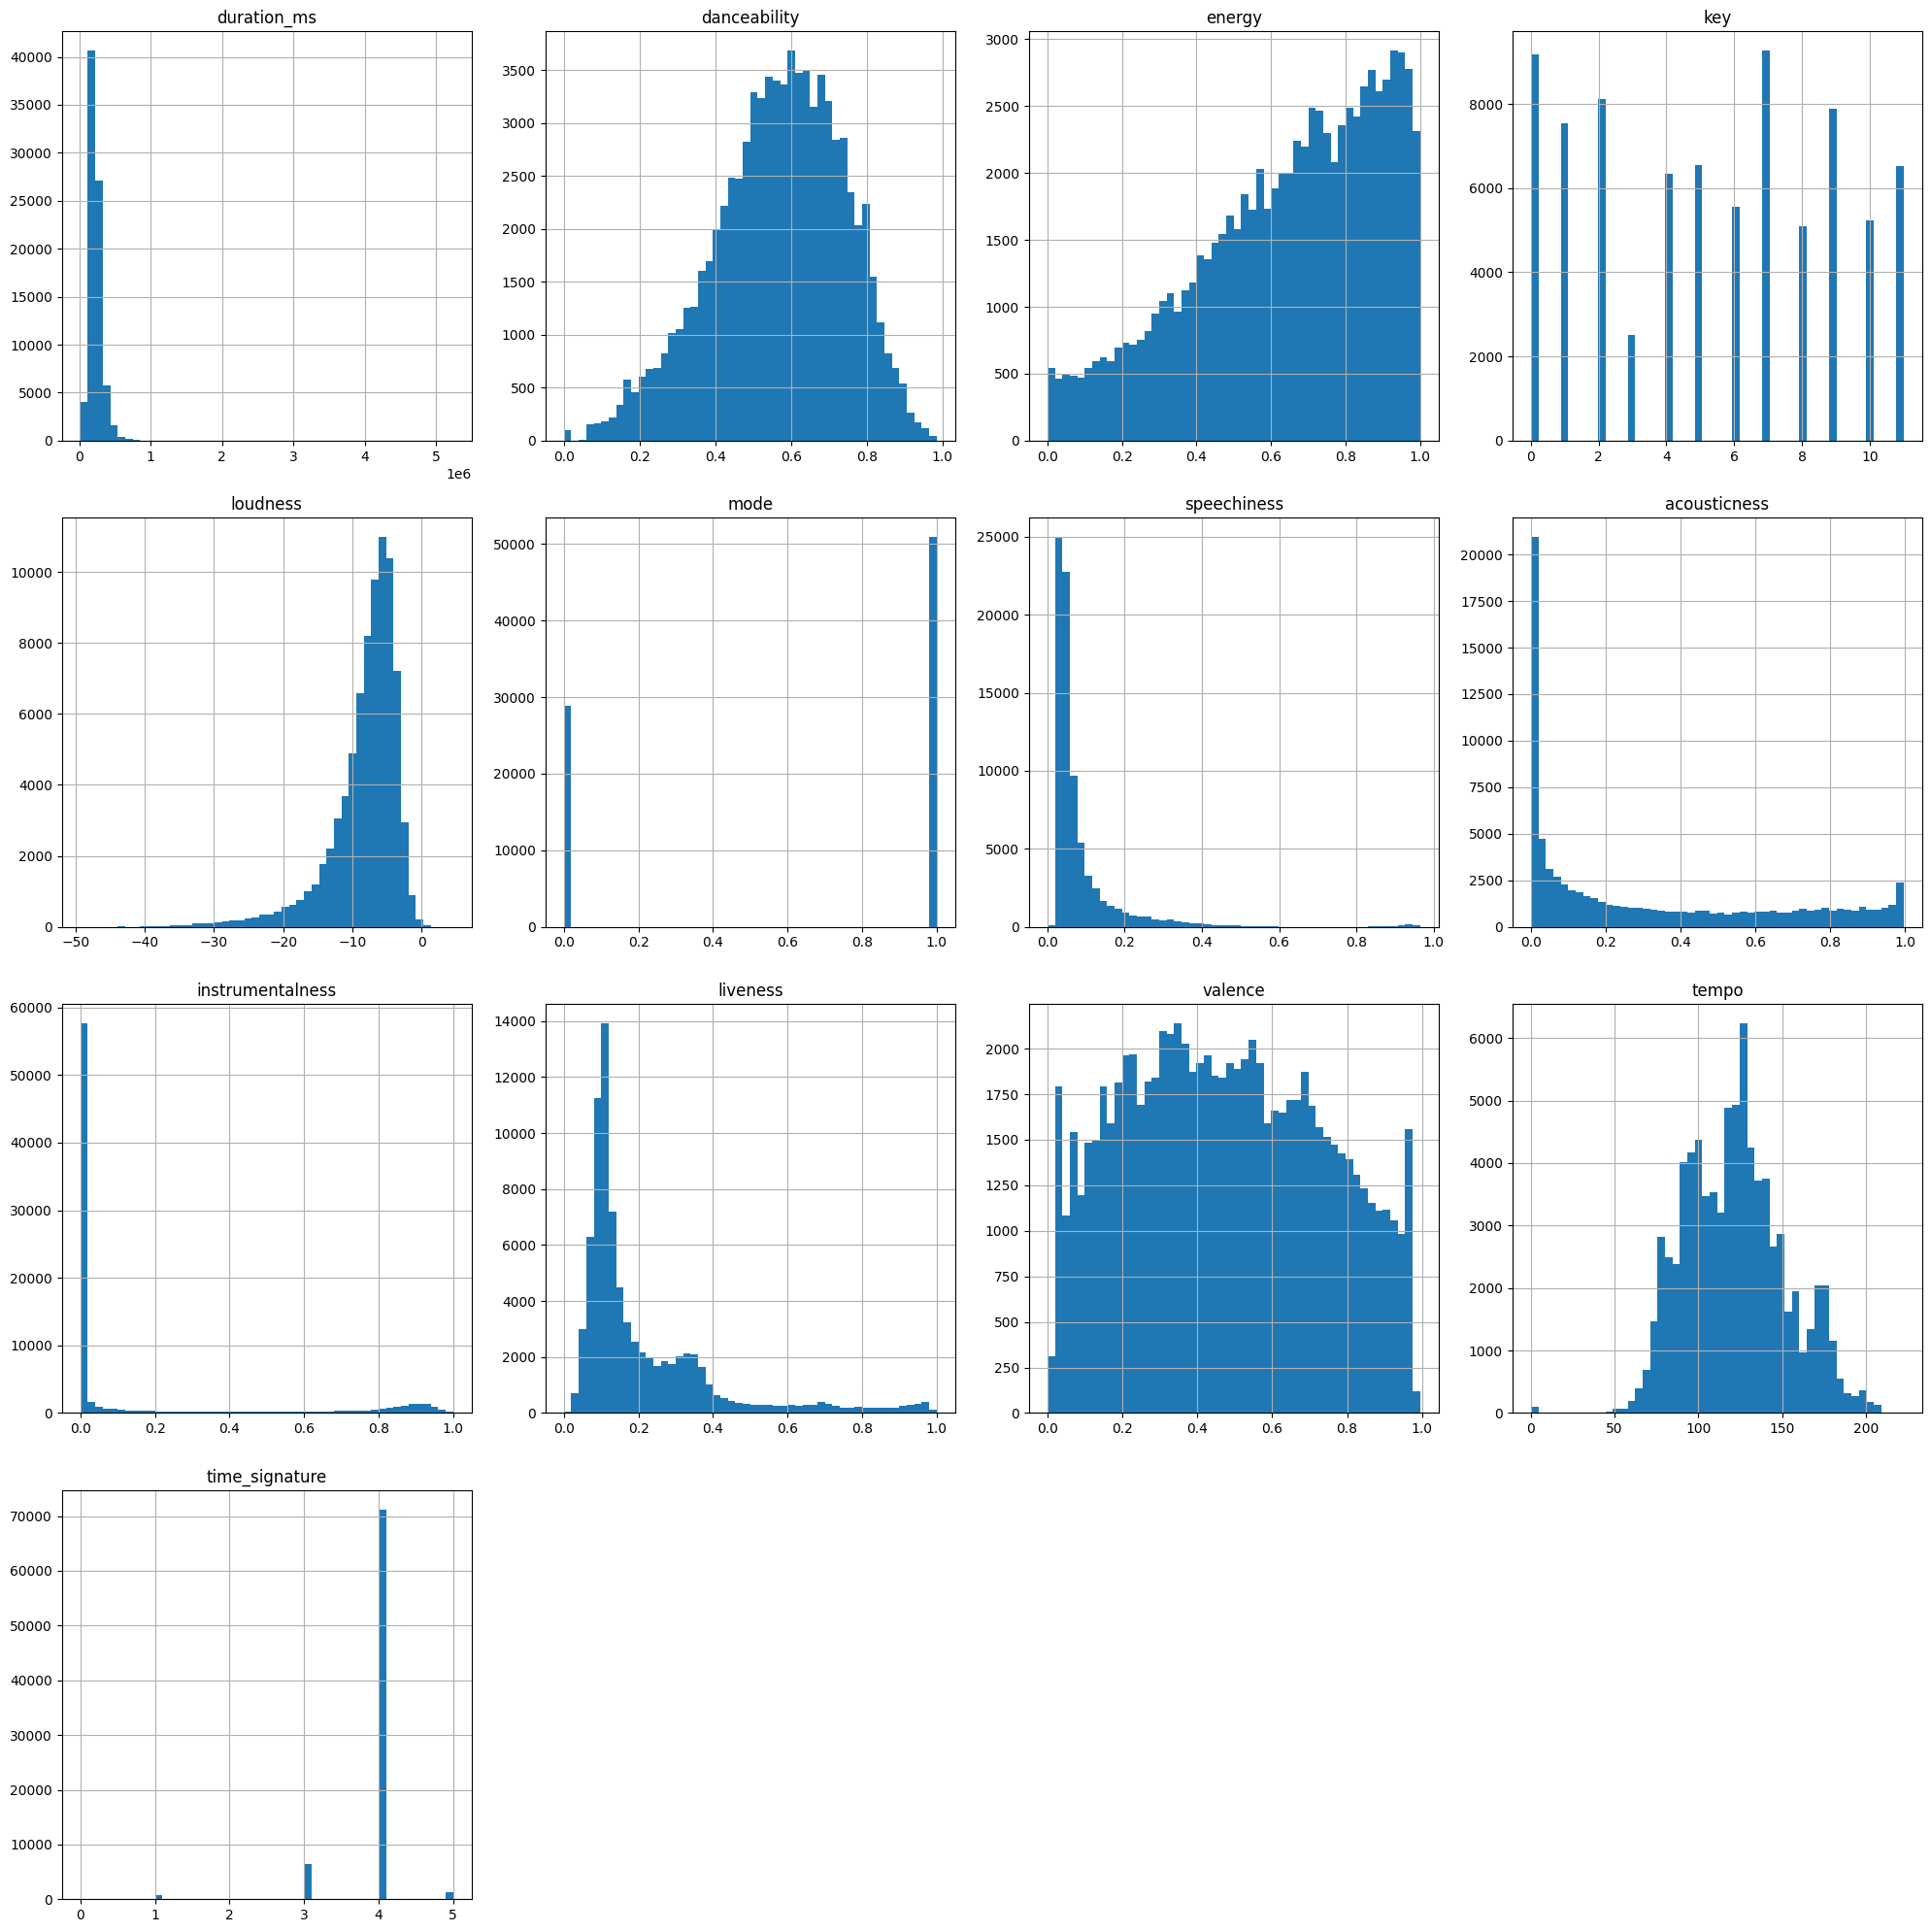

In [83]:
# Histogramas de frecuencias
dataTraining.drop(columns=["popularity", "Unnamed__0"]).hist(figsize=(20,20), bins=50)
plt.tight_layout()
plt.show()

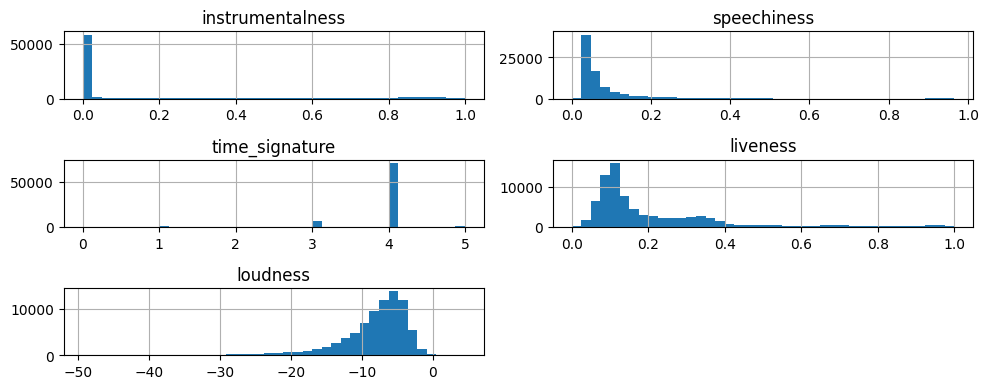

In [84]:
# Revisar variables sospechosas con altos outliers

vars_outliers = ['instrumentalness','speechiness','time_signature','liveness','loudness']

dataTraining[vars_outliers].hist(figsize=(10,4), bins=40)
plt.tight_layout()
plt.show()

In [86]:
# Relación de las variables con altos outliers y la variable objetivo
dataTraining.groupby("popularity")[vars_outliers].mean()

,instrumentalness,speechiness,time_signature,liveness,loudness
popularity,,,,,
0,0.105113,0.073927,3.888513,0.186312,-8.245586
1,0.072365,0.075380,3.907148,0.179631,-7.195597
2,0.082160,0.088747,3.934266,0.180168,-6.884088
3,0.116740,0.099197,3.881612,0.190402,-7.360725
4,0.204363,0.089485,3.912727,0.177185,-7.750684
...,...,...,...,...,...
96,0.000305,0.048180,4.000000,0.068400,-6.995400
97,0.000140,0.155114,4.000000,0.107314,-5.144857
98,0.000004,0.035560,4.000000,0.279200,-4.666600


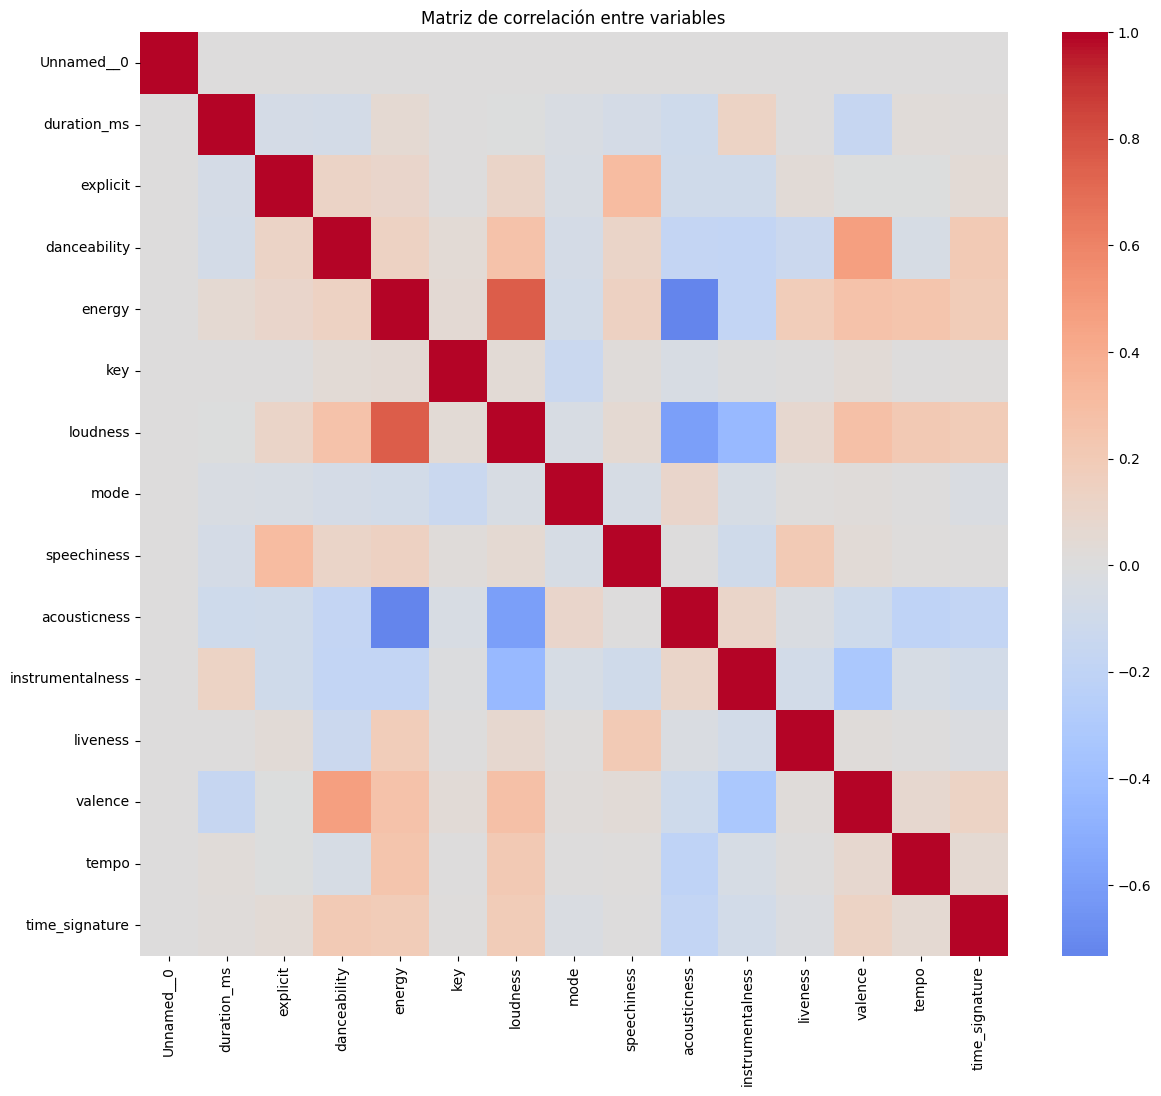

In [89]:
# Análisis de correlación
plt.figure(figsize=(14,12))
sns.heatmap(
    dataTraining.drop(columns=['popularity','track_id','artists','track_genre','album_name','track_name']).corr(),
    cmap="coolwarm", center=0
)
plt.title("Matriz de correlación entre variables")
plt.show()

In [91]:
cols_drop = ['popularity','track_id','artists','track_genre','album_name','track_name']

corr_matrix = dataTraining.drop(columns=cols_drop).corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

corr_pairs = upper.stack().reset_index()
corr_pairs.columns = ["variable_1", "variable_2", "correlacion"]
corr_pairs = corr_pairs[corr_pairs["correlacion"] > 0.7]
corr_pairs = corr_pairs.sort_values("correlacion", ascending=False)
corr_pairs

,variable_1,variable_2,correlacion
51,energy,loudness,0.762022
54,energy,acousticness,0.733561


In [133]:
# Columnas a usar
cols_drop = ['popularity','track_id','artists','track_genre','album_name','track_name','Unnamed_0']
X_train_fs = X_train.drop(columns=[c for c in cols_drop if c in X_train.columns])
X_test_fs  = X_test.drop(columns=[c for c in cols_drop if c in X_test.columns])

# F-test para regresión
F_scores, p_values = f_regression(X_train_fs, y_train)

# Tabla de resultados
f_table = pd.DataFrame({
    "Variable": X_train_fs.columns,
    "F_score": F_scores,
    "p_value": p_values
}).sort_values("F_score", ascending=False)

print(f_table.to_string(index=False))

# Selección por p-value
vars_keep = f_table.loc[f_table["p_value"] < 0.1, "Variable"].tolist()

X_train_reduced = X_train_fs[vars_keep].copy()
X_test_reduced  = X_test_fs[vars_keep].copy()

print("\nVariables originales:", X_train_fs.shape[1])
print("Variables seleccionadas:", X_train_reduced.shape[1])

        Variable    F_score       p_value
instrumentalness 586.400353 5.823027e-129
        loudness 169.845445  8.963429e-39
     speechiness 131.157379  2.449015e-30
        explicit 121.177260  3.704772e-28
         valence 110.587491  7.649384e-26
    danceability  85.267534  2.683053e-20
  time_signature  83.581720  6.287080e-20
    acousticness  46.955123  7.328710e-12
           tempo  14.230185  1.619009e-04
            mode  12.609270  3.841145e-04
        liveness   6.178191  1.293599e-02
     duration_ms   5.610699  1.785410e-02

Variables originales: 12
Variables seleccionadas: 12


In [93]:
vars_keep

['instrumentalness',
 'loudness',
 'speechiness',
 'explicit',
 'valence',
 'danceability',
 'time_signature',
 'acousticness',
 'tempo',
 'mode',
 'liveness',
 'duration_ms']

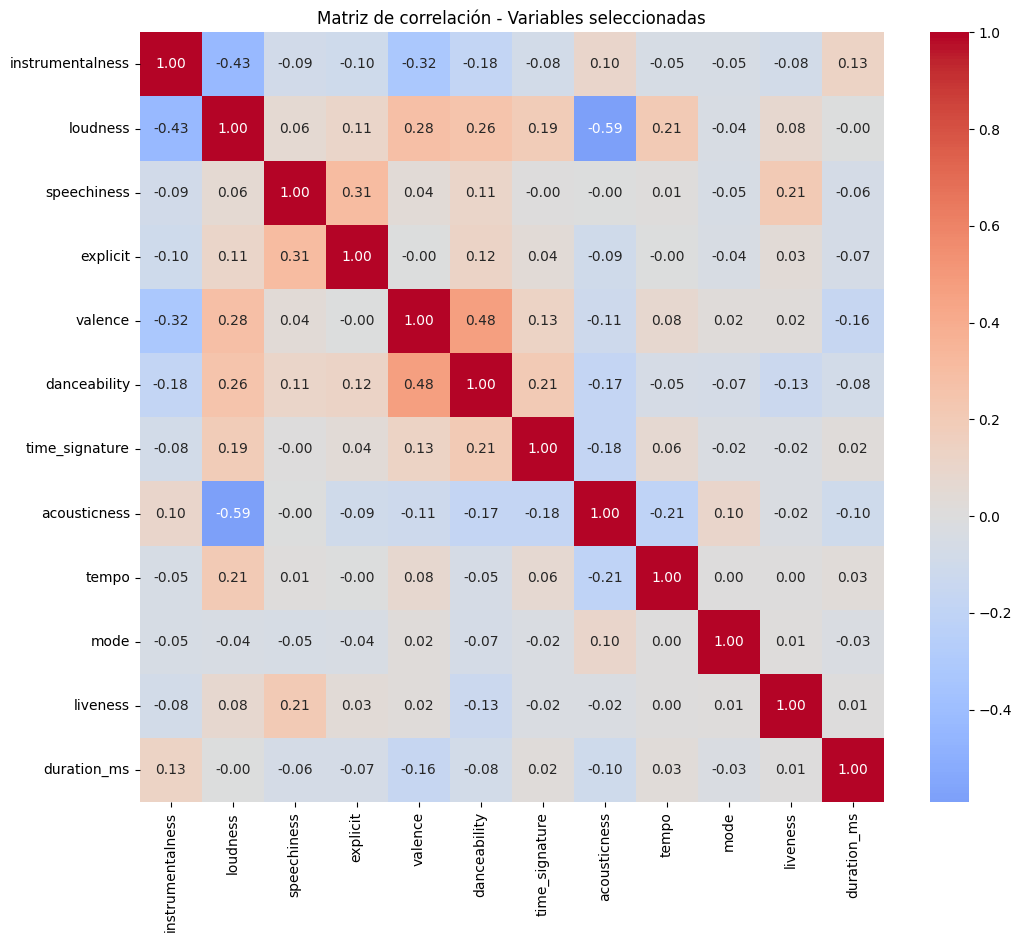

,variable_1,variable_2,correlacion


In [104]:
# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(dataTraining[vars_keep].corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Matriz de correlación - Variables seleccionadas")
plt.show()

# Tabla pares con alta correlación
corr_matrix = dataTraining[vars_keep].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

corr_pairs = upper.stack().reset_index()
corr_pairs.columns = ["variable_1", "variable_2", "correlacion"]
corr_pairs = corr_pairs[corr_pairs["correlacion"] > 0.7]
corr_pairs.sort_values("correlacion", ascending=False)

In [105]:
# 2. Redefinir X_train y X_test con solo esas variables
X_train_reduced = X_train[vars_keep].copy()
X_test_reduced  = X_test[vars_keep].copy()


### Calibración del modelo (15 puntos)

Se calibran los parámetros que se consideren pertinentes del modelo seleccionado. (5 puntos)

Se justifica el método seleccionado de calibración. (5 puntos)

Se analizan los valores calibrados de cada parámetro y se explica cómo afectan el modelo. (5 puntos)

In [137]:
# Redefinir X_train y X_test con solo variables del proceso exploratorio

# Opción A: todas las variables
X_train = X_train_orig.copy()
X_test  = X_test_orig.copy()

# Opción B: variables reducidas por f-score
# X_train = X_train_orig[vars_keep].copy()
# X_test  = X_test_orig[vars_keep].copy()

In [138]:
# Arbol de decision
# Definición y entrenamiento
dt_simple = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_simple.fit(X_train, y_train)

# Predicción y error
y_pred_dt = dt_simple.predict(X_test)
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))

RMSE: 21.71556031952924


In [139]:
# Votacion ponderada
# Definición de 4 modelos diferentes: regresión logística, árbol de decisión,Navie Bayes y k vecinos más cercanos
models = {'lr': LinearRegression(),
          'dt': DecisionTreeRegressor(),
          'nb': GaussianNB(),
          'kn': KNeighborsRegressor()}

In [140]:
# Entrenamiento (fit) de cada modelo
for model in models.keys():
    models[model].fit(X_train, y_train)

In [141]:
# Predicciones
y_pred_varios = pd.DataFrame(index=X_test.index, columns=models.keys())

for model in models.keys():
    y_pred_varios[model] = models[model].predict(X_test)

In [142]:
for model in models.keys():
    print(model,np.sqrt(mean_squared_error(y_pred_varios[model], y_test)))


lr 21.964401065030707
dt 22.132001968489185
nb 39.50886848826549
kn 21.337026544352096


In [143]:
# Pesos
pesos = {'lr': 0.6, 'dt': 0.15, 'nb': 0.05, 'kn': 0.02}  # deben sumar 1

y_pred_ponderado = sum(
    pesos[m] * models[m].predict(X_test)
    for m in models.keys()
)

# Cálculo del error del modelo
np.sqrt(mean_squared_error(y_test, y_pred_ponderado))

np.float64(21.667717516465476)

In [144]:
# Bagging
bagreg = BaggingRegressor(DecisionTreeRegressor(), n_estimators=10,
                          bootstrap=True, oob_score=True, random_state=1)

bagreg.fit(X_train, y_train)
y_pred_bagg = bagreg.predict(X_test)

# Cálculo del error del modelo
np.sqrt(mean_squared_error(y_test, y_pred_bagg))

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_bagging.py:1315: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(


np.float64(16.91453819484979)

In [145]:

# Definición
models = {
    'rf':   RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    # 'et':   ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'gb':   GradientBoostingRegressor(n_estimators=100, random_state=42),
    'ada':  AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=5),
                              n_estimators=100, random_state=42),
    'hgb':  HistGradientBoostingRegressor(max_iter=100, random_state=42),
    'xgb':  xgb.XGBRegressor(n_estimators=100, random_state=42,
                              verbosity=0, n_jobs=-1),
    'lgb':  lgb.LGBMRegressor(n_estimators=100, random_state=42,
                               verbosity=-1, n_jobs=-1)
}

# Entrenamiento y evaluación
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results[name] = rmse
    print(f"{name}: RMSE = {rmse:.4f}")

# Ranking
print("\n--- Ranking ---")
for name, rmse in sorted(results.items(), key=lambda x: x[1]):
    print(f"{name}: {rmse:.4f}")

rf: RMSE = 15.9977
gb: RMSE = 21.2166
ada: RMSE = 21.7010
hgb: RMSE = 20.2646
xgb: RMSE = 19.1814
lgb: RMSE = 20.2332

--- Ranking ---
rf: 15.9977
xgb: 19.1814
lgb: 20.2332
hgb: 20.2646
gb: 21.2166
ada: 21.7010


In [148]:
rf_model = models['rf']

importancias = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': rf_model.feature_importances_
}).sort_values('Importancia', ascending=False)

print(importancias.to_string(index=False))

        Variable  Importancia
    acousticness     0.103324
    danceability     0.099455
         valence     0.098428
     duration_ms     0.098390
           tempo     0.098069
     speechiness     0.097783
        loudness     0.093666
          energy     0.087259
        liveness     0.087143
instrumentalness     0.071617
             key     0.042099
            mode     0.009650
        explicit     0.006957
  time_signature     0.006159


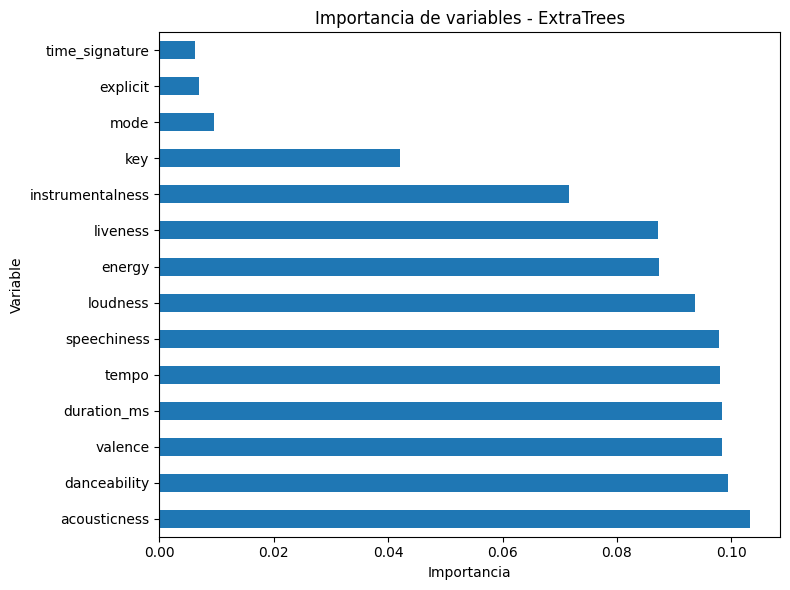

In [149]:
importancias.plot(kind='barh', x='Variable', y='Importancia',
                  figsize=(8,6), legend=False)
plt.title("Importancia de variables - ExtraTrees")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

In [151]:
# Umbral de corte
umbral_fscore = 0.1
umbral_importancia = 0.02

# F-score (ya calculado antes)
f_table_idx = f_table.set_index('Variable')

# Feature importance RF
importancias_idx = importancias.set_index('Variable')

# Unir ambos en una sola tabla
comparacion = pd.DataFrame({
    'F_score': f_table_idx['F_score'],
    'p_value': f_table_idx['p_value'],
    'Importancia_RF': importancias_idx['Importancia']
}).dropna()

# Flags de eliminación por cada método
comparacion['eliminar_fscore']      = comparacion['p_value'] > umbral_fscore
comparacion['eliminar_importancia'] = comparacion['Importancia_RF'] < umbral_importancia

# Coincidencia: ambos métodos recomiendan eliminar
comparacion['eliminar_ambos'] = comparacion['eliminar_fscore'] & comparacion['eliminar_importancia']

comparacion = comparacion.sort_values('Importancia_RF', ascending=False)

print(comparacion.to_string())
print("\n--- Eliminar con seguridad (coinciden ambos métodos) ---")
print(comparacion[comparacion['eliminar_ambos']].index.tolist())

print("\n--- Solo f-score recomienda eliminar ---")
print(comparacion[comparacion['eliminar_fscore'] & ~comparacion['eliminar_importancia']].index.tolist())

print("\n--- Solo feature importance recomienda eliminar ---")
print(comparacion[~comparacion['eliminar_fscore'] & comparacion['eliminar_importancia']].index.tolist())

                     F_score        p_value  Importancia_RF  eliminar_fscore  eliminar_importancia  eliminar_ambos
Variable                                                                                                          
acousticness       46.955123   7.328710e-12        0.103324            False                 False           False
danceability       85.267534   2.683053e-20        0.099455            False                 False           False
valence           110.587491   7.649384e-26        0.098428            False                 False           False
duration_ms         5.610699   1.785410e-02        0.098390            False                 False           False
tempo              14.230185   1.619009e-04        0.098069            False                 False           False
speechiness       131.157379   2.449015e-30        0.097783            False                 False           False
loudness          169.845445   8.963429e-39        0.093666            False    

In [150]:
# Eliminar variables de baja importancia
vars_drop = ['mode', 'explicit', 'time_signature']
vars_rf = [c for c in X_train.columns if c not in vars_drop]

X_train_rf = X_train[vars_rf].copy()
X_test_rf  = X_test[vars_rf].copy()

# Reentrenar solo RF con variables reducidas
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_rf, y_train)

y_pred_rf = rf_model.predict(X_test_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"RMSE con 12 variables: 16.0446")
print(f"RMSE con 9 variables:  {rmse_rf:.4f}")
print(f"Diferencia:            {16.0446 - rmse_rf:.4f}")

RMSE con 12 variables: 16.0446
RMSE con 9 variables:  16.0283
Diferencia:            0.0163


In [153]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Grilla de hiperparámetros
param_grid = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        [None, 10, 20, 30],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features':     ['sqrt', 'log2', None]
}

# Búsqueda aleatoria
search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=30,          # prueba 30 combinaciones aleatorias
    cv=5,               # validación cruzada 5 folds
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train_rf, y_train)

# Resultados
print("Mejores hiperparámetros:")
print(search.best_params_)

print(f"\nRMSE CV (train):  {-search.best_score_:.4f}")

y_pred_tuned = search.best_estimator_.predict(X_test_rf)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

print(f"RMSE sin calibrar: 16.0283")
print(f"RMSE calibrado:    {rmse_tuned:.4f}")
print(f"Mejora:            {16.0283 - rmse_tuned:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [ ]:
# Ver generalizacion
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    search.best_estimator_,
    X_train_rf, y_train,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

print(f"RMSE por fold: {[-s for s in scores.round(4)]}")
print(f"RMSE promedio: {-scores.mean():.4f}")
print(f"Desviación:    {scores.std():.4f}")

### Entrenamiento del modelo (15 puntos)

Se entrena un modelo apropiado para el problema con los datos del set de entrenamiento preprocesados y los parámetros óptimos. (5 puntos)

Se presenta el desempeño del modelo en los datos de validación con al menos una métrica de desempeño. (5 puntos)

Se justifica la selección del modelo correctamente. (5 puntos)

In [ ]:
# Guardar predicciones en formato exigido en la competencia de kaggle
y_pred.to_csv('test_submission_file.csv', index_label='ID')
y_pred.head()

### Disponibilización del modelo (30 puntos)

Se disponibiliza el modelo en una API alojada en un servicio en la nube. (20 puntos)

Se hacen las predicciones sobre la popularidad en la canción en al menos dos observaciones del set de validación. (10 puntos)

### Conclusiones (10 puntos)
Se presentan conclusiones claras y concisas sobre el desarrollo y los resultados del proyecto. (10 puntos)